<tabel>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Teks disediakan di bawah lisensi Creative Commons Attribution, CC-BY. Semua kode tersedia di bawah lisensi MIT yang disetujui FSF. (c) Kyle T. Mandli</td>
</tabel>

In [ ]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# Persamaan Hiperbolik - Bagian I

Persamaan hiperbolik sudah kita kenal dan muncul di banyak model sistem fisik serta model lain yang berperilaku seperti gelombang.  Salah satu PDE hiperbolik paling dasar adalah persamaan adveksi
 $$
    u_t + a u_x = 0
$$ 
dimana $u(x,t)$ yang tidak diketahui adalah sejumlah besaran yang diangkut oleh aliran dengan kecepatan $a$ .  Persamaan ini akan menjadi dasar diskusi kita mengenai topik luas ini.

Untuk permasalahan Cauchy (domain spasial tak hingga) kita hanya memerlukan kondisi awal $u(x,0) = u_0(x)$ yang dengannya kita dapat segera menuliskan solusi PDE sederhana ini sebagai
 $$
    u(x,t) = u_0(x - a t).
$$ 
Kesederhanaan ini memungkiri kompleksitas ketika menyangkut metode numerik untuk menyelesaikan persamaan ini.  Untungnya persamaan ini menunjukkan banyak kesulitan numerik dalam menyelesaikan PDE hiperbolik yang lebih kompleks namun sangat mudah untuk diselesaikan.

Jika kita mempunyai batas terbatas pada persamaan adveksi, perhatikan bahwa untuk konsistensi kita hanya memerlukan satu batas, yang disebut batas aliran masuk, dan tidak ada batas aliran keluar.  Batas mana yang ditentukan oleh arah aliran yaitu tanda $a$ .  Secara numerik hal ini dapat menyebabkan masalah tergantung pada diskritisasi yang kita gunakan (misalnya jika kita memerlukan titik dari batas aliran keluar).  Sebaliknya dalam praktiknya kita akan menyiasatinya dengan menetapkan batas secara numerik yang tidak bertentangan dengan solusi yang ada atau dengan menggunakan pendekatan satu sisi yang berbeda.  Kita akan membahas masalah ini nanti, tetapi ada baiknya kita menyadari hal ini saat kita berdiskusi.

## Diskritisasi Pertama

Pendekatan pertama mungkin mendiskritisasi persamaan ini dengan metode forward Euler dalam waktu dan orde kedua, memusatkan perbedaan dalam ruang yang mengarah pada diskritisasi.
 $$
    \frac{U^{n+1}_j - U^n_j}{\Delta t} = \frac{a}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})
$$ 
atau 
 $$
    U^{n+1}_j = U^n_j + \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$ 
Ternyata metode ini tidak terlalu berguna dalam praktiknya seperti yang akan terlihat ketika mempertimbangkan stabilitas.

Metode lain yang merupakan modifikasi kecil dari metode di atas disebut *metode Lax-Friedrichs*
 $$
    U^{n+1}_j = \frac{1}{2}(U^n_{j-1} + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$ 
Metode ini menggantikan evaluasi tunggal $U^n_j$ dengan rata-rata spasial.  Meskipun pendekatan ini memiliki sifat stabilitas yang lebih baik (stabil Lax-Richtmyer), pendekatan ini masih jarang digunakan dalam praktik.

Diskritisasi umum lainnya dari persamaan adveksi ditemukan dari Leapfrog (titik tengah).  Dengan menggunakan pendekatan ini kami menemukan
 $$
    \frac{U^{n+1}_j - U^{n-1}_j}{2 \Delta t} + a \frac{U^n_{j+1} - U^n_{j-1}}{2 \Delta x} = 0
$$ 
atau dalam bentuk pembaruan
 $$
    U^{n+1}_j = U^{n-1}_j - \frac{a \Delta t }{\Delta x} (U^n_{j+1} - U^n_{j-1}).
$$

Satu catatan terakhir sebelum beralih ke analisis konvergensi berkaitan dengan hubungan antara $\Delta t$ dan $\Delta x$ .  Untuk metode Lax-Friedrichs misalnya kita akan mencari hubungannya
 $$
    \left | \frac{a \Delta t}{\Delta x} \right | \leq 1
$$ 
yang, selain $a$ , menunjukkan bahwa $\Delta t$ dan $\Delta x$ dapat berubah dengan urutan yang sama!  Hal ini membawa kita pada kesimpulan umum bahwa PDE hiperbolik sebenarnya tidak terlalu kaku secara umum dibandingkan PDE parabola karena adanya turunan yang terlibat.  Inilah sebabnya mengapa PDE hiperbolik dapat diselesaikan secara efektif dengan menggunakan diskritisasi loncatan waktu yang eksplisit dibandingkan dengan diskritisasi implisit yang kami anggap berguna untuk PDE parabola.

### Contoh Soal:
Diberikan persamaan adveksi:

$ u_t + u_x = 0 $

dengan kondisi awal:
$ u(x,0) = sin(x) $

Gunakan metode Forward Euler dan beda hingga pusat untuk menghitung solusi numerik hingga t = 1.

### Penyelesaian Langkah demi Langkah

#### 1. Persamaan yang diberikan
u_t + u_x = 0

#### 2. Tujuan
Mencari solusi numerik u(x,t) menggunakan diskritisasi.

#### 3. Diskritisasi waktu (Forward Euler)
Turunan waktu:
u_t ≈ (U_j^{n+1} - U_j^n) / Δt

#### 4. Diskritisasi ruang (Central Difference)
Turunan ruang:
u_x ≈ (U_{j+1}^n - U_{j-1}^n) / (2Δx)

#### 5. Substitusi ke persamaan
(U_j^{n+1} - U_j^n)/Δt + (U_{j+1}^n - U_{j-1}^n)/(2Δx) = 0

#### 6. Susun ulang untuk mencari U^{n+1}
U_j^{n+1} = U_j^n - (Δt/(2Δx))(U_{j+1}^n - U_{j-1}^n)

#### 7. Langkah komputasi
1. Tentukan grid ruang: x_j
2. Tentukan Δx dan Δt
3. Inisialisasi kondisi awal: U_j^0 = sin(x_j)
4. Hitung U_j^{n+1} untuk semua j
5. Ulangi sampai waktu akhir

#### 8. Solusi eksak (pembanding)
u(x,t) = sin(x - t)

#### 9. Catatan penting
Metode ini:
- Sederhana
- Tidak stabil untuk banyak kasus

'Simulasi selesai'

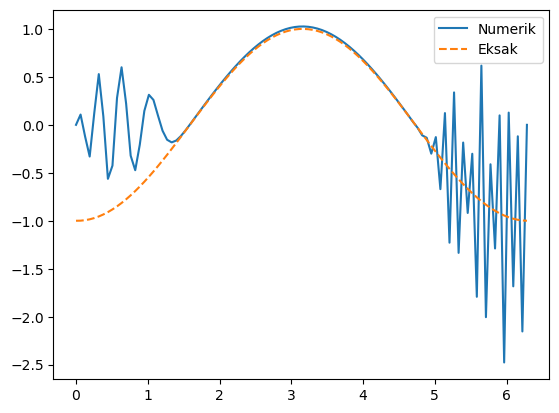

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Parameter
nx = 100
x = np.linspace(0, 2*np.pi, nx)
dx = x[1] - x[0]
dt = 0.5 * dx
nt = 50

# Kondisi awal
u = np.sin(x)

# Iterasi Forward Euler + Central Difference
for n in range(nt):
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] - dt/(2*dx) * (u[2:] - u[:-2])
    u = u_new

display("Simulasi selesai")

plt.plot(x, u, label="Numerik")
plt.plot(x, np.sin(x - nt*dt), '--', label="Eksak")
plt.legend()
plt.show()

## Metode Diskritisasi Garis

Sebagai langkah pertama dalam memahami stabilitas diskritisasi yang disebutkan di atas, mari kita rumuskan persamaan adveksi dalam pendekatan metode garis dan menganalisis stabilitas dalam kaitannya dengan masalah nilai awal.

Untuk mempertimbangkan semua metode sebelumnya, kita akan mengasumsikan kondisi batas periodik (sehingga metode tersebut tidak mempunyai masalah aliran masuk/aliran keluar).  Kondisi batas ini terlihat seperti ini
 $$
    u(0, t) = u(1, t), ~~~ \text{for}~ t \geq 0
$$ 
di mana kami memilih $\Omega = [0, 1]$ untuk kesederhanaan.  Pengaturan ini juga mirip dengan masalah Cauchy yang asli.

Kami sekarang memperkenalkan vektor yang tidak diketahui
 $$
    U = \begin{bmatrix}
        U_1(t) \\ U_2(t) \\ \vdots \\ U_m(t) \\ U_{m+1}(t)
    \end{bmatrix}
$$ 
di mana kami telah menyertakan nilai ekstra di $x_{m+1}$ dengan gagasan bahwa $U_0(t) = U_{m+1}(t)$ .  Dengan menggunakan diskritisasi ini kita mempunyai sistem ODE

 $$
    U'_j(t) = -\frac{a}{2 \Delta x} \left \{ \begin{aligned}
        &(U_2(t) - U_{m+1}(t)) & & j = 1 \\
        &(U_{j+1}(t) - U_{j-1}(t)) & & 2 \leq j \leq m \\
        &(U_1(t) - U_{m}(t)) & & j = m + 1
    \end{aligned} \right .
$$

Hal ini mengarah ke sistem $U'(t) = A U(t)$ dengan
 $$
    A = -\frac{a}{2 \Delta x} \begin{bmatrix}
        0  &  1 &  & & & -1\\
        -1 &  0 & 1 \\
           & -1 & 0 & 1 \\
         & & \ddots & \ddots & \ddots \\
         & & & -1 & 0 & 1 \\
         1 & & & & -1 & 0 \\
    \end{bmatrix}.
$$ 
Nilai di sudut menunjukkan banyak PDE dengan kondisi batas periodik.

Matriks $A$ ternyata *simetris miring* ( $A^T = - A$ ) yang menyiratkan bahwa nilai eigennya murni imajiner.  Nilai eigen ini adalah

 $$
    \lambda_p = -\frac{i a}{\Delta x} \sin(2 \pi p \Delta x) \quad \text{for } p = 1, 2, \ldots , m+1
$$ 
dengan vektor eigen yang sesuai
 $$
    u^p_j = e^{2 \pi i p j / \Delta x} \quad \text{for} ~ j = 1, 2, \ldots m + 1.
$$

Mengingat semua nilai eigen terletak di sepanjang sumbu imajiner
 $$
    \lambda \in \left[ -\frac{i a}{\Delta x}, \frac{i a}{\Delta x} \right]
$$ 
disimpulkan bahwa dengan diskritisasi spasial di atas diperlukan suatu metode dengan daerah kestabilan absolut yang mencakup sumbu imajiner
 $$
    z \in \left[ -\frac{i a \Delta t}{\Delta x}, \frac{i a \Delta t}{\Delta x} \right]
$$ 
sekarang juga dengan mempertimbangkan $\Delta t$ .  Metode yang mungkin kemudian mencakup metode titik tengah, dan beberapa metode Adams mungkin cocok sedangkan metode BDF tidak.

### Contoh: Teruskan Euler

Pendekatan pertama yang kami sajikan di atas menggunakan diskritisasi Euler ke depan dalam waktu.  Jika kita melihat wilayah stabilitas absolut kita tahu
 $$
    |1 + \Delta t \lambda| \leq 1
$$ 
yang merupakan lingkaran satuan yang berpusat di -1.  Rasio $\Delta t / \Delta x$ tidak akan pernah menghasilkan metode yang stabil karena wilayah ini hanya mencakup titik $z = 0$ dalam skenario ini.  Jika sebaliknya kita membiarkan $\Delta t$ menuju ke nol lebih cepat dari $\Delta x$ kita mungkin dapat menyebabkan $\lambda_p$ dari matriks menyusut ke titik asal.

Dalam pembahasan stabilitas Lax-Richtmyer kami menggunakan batas terlemah di sini $||B|| \leq 1 + \alpha \Delta t$ di mana $B = I + \Delta t A$ .  Menggunakan fakta bahwa $\lambda_p$ adalah murni khayalan dan memilih $\Delta t = \Delta x^2$ kita tahu
 $$\begin{aligned}
    | 1 + \Delta t \lambda_p |^2 &\leq 1 + \left(\frac{a \Delta t}{\Delta x}\right)^2 \\
    & \leq 1 + a^2 \Delta x^2 = 1 + a^2 \Delta t.
\end{aligned}$$ 
Kita kemudian dapat mengikat $||B||$ dengan
 $$
    ||B|| \leq 1 + \alpha \Delta t
$$ 
dengan $\alpha = a^2$ .  Jika $n \Delta t \leq T$ maka kita mengetahuinya
 $$
    \left\|(I + \Delta t A)^n \right\|_2 \leq (1 + a^2 \Delta t)^{n / 2} \leq e^{a^2 T / 2}
$$ 
dan karenanya metode ini stabil pada Lax-Richtmyer.

### Contoh: Lax-Friedrichs

Penting untuk menulis ulang metode Lax-Friedrichs di atas
 $$
    U^{n+1}_j = \frac{1}{2}(U^n_{j-1} + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})
$$ 
menggunakan fakta itu 
 $$
    \frac{1}{2}(U^n_{j-1} + U^n_{j+1}) = U^n_j + \frac{1}{2} (U^n_{j-1} - 2 U^n_j + U^n_{j+1})
$$ 
sebagai
 $$
    U^{n+1}_j = U^n_j + \frac{1}{2} (U^n_{j-1} - 2 U^n_j + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$ 

Perhatikan kesamaan antara rata-rata tertimbang yang baru dan stensil untuk perkiraan perbedaan terpusat orde kedua dengan turunan kedua.

Hal ini dapat diatur ulang lebih lanjut untuk memberi kita interpretasi diskritisasi langsung terhadap metode tersebut
 $$
    \frac{U^{n+1}_j - U^n_j}{\Delta t} + a \left(\frac{U^n_{j+1} - U^n_{j-1}}{2 \Delta x} \right ) = \frac{\Delta x^2}{2 \Delta t} \left( \frac{U^n_{j-1} - 2 U^n_j + U^n_{j+1}}{\Delta x^2} \right ).
$$

Memeriksa konsistensi pendekatan di sebelah kiri mengarah ke

 $$\begin{aligned}
    &\frac{1}{\Delta t} \left [ u + \Delta t u_t + \frac{\Delta t^2}{2} u_{tt} + \frac{\Delta t^3}{6} u_{ttt} + \mathcal{O}(\Delta t^4) - u \right ] \\
    & \quad \quad + \frac{a}{2 \Delta x}\left [ u + \Delta x u_x + \frac{\Delta x^2}{2} u_{xx} + \frac{\Delta x^3}{6} u_{xxx} -u + \Delta x u_x - \frac{\Delta x^2}{2} u_{xx} + \frac{\Delta x^3}{6} u_{xxx}) + \mathcal{O}(\Delta x^4) \right ] \\
    &= u_t + a u_x + \frac{\Delta t}{2} u_{tt} + \frac{\Delta t^2}{6} u_{ttt} + a \frac{\Delta x^2}{6} u_{xxx} + \mathcal{O}(\Delta t^3) + \mathcal{O}(\Delta x^3)
\end{aligned}$$ 

jadi kita dapat menyimpulkan bahwa dengan ruas kiri saja kita akan konsisten tetapi kita memiliki suku tambahan!

Memperluas sisi kanan dalam deret Taylor yang kita lihat
 $$\begin{aligned}
    \frac{\Delta x^2}{2 \Delta t} \left(u_{xx} + \frac{\Delta x^2}{12} u_{xxxx} + \mathcal{O}(\Delta x^4) \right ) 
\end{aligned}$$ 
mengarah pada kesimpulan bahwa ini adalah diskritisasi persamaan adveksi-difusi
 $$
    u_t + a u_x = \epsilon u_{xx}
$$ 
dimana
 $$
    \epsilon = \frac{\Delta x^2}{2 \Delta t}.
$$

Kita dapat menulis ulang sistem ini sebagai $U'(t) = A_\epsilon U(t)$ dimana
 $$
    A_\epsilon = -\frac{a}{2 \Delta t} \begin{bmatrix}
        0  &  1 &  & & & -1\\
        -1 &  0 & 1 \\
           & -1 & 0 & 1 \\
         & & \ddots & \ddots & \ddots \\
         & & & -1 & 0 & 1 \\
         1 & & & & -1 & 0 \\
    \end{bmatrix} + \frac{\epsilon}{\Delta x^2} \begin{bmatrix}
        -2 & 1 & & & & 1\\
        1 & -2 & 1 \\
        & 1 & -2 & 1 \\
        & & \ddots & \ddots & \ddots \\
        & & & 1 & - 2 & 1 \\
        1 & & & & 1 & -2 
    \end{bmatrix}.
$$ 
Perhatikan secara khusus bahwa ini adalah matriks $A$ yang sama dengan diskritisasi Euler maju ketika $\epsilon = 0$ .  Karena suku tambahan di $A_\epsilon$ menyebabkan matriks tidak lagi simetris miring melainkan simetris, kami memperkirakan nilai eigen tidak lagi murni imajiner.  Istilah tambahan ini dapat dilihat sebagai *regularisasi* atau *relaksasi* dari masalah asli melalui istilah difusif.  Penting juga untuk dicatat bahwa banyak diskritisasi praktis dari persamaan adveksi seringkali bersifat difusif baik sebagai konsekuensi dari diskritisasi atau sebagai fitur bawaan seperti yang kita lihat di sini.

In [ ]:
# Implement Lax-Friedrichs for the PDE u_t + u_x = 0 on a periodic
# domain
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

m = 501
x = numpy.linspace(0, 25.0, m)
delta_x = 25.0 / (m - 1)
cfl = 0.8
delta_t = cfl * delta_x

U = u_true(x, 0)
U_new = numpy.empty(U.shape)
t = 0.0
t_final = 17.0
while t < t_final:
    U_new[0] = 0.5 * (U[1] + U[-1]) - delta_t / (2.0 * delta_x) * (U[1] - U[-1])
    U_new[1:-1] = 0.5 * (U[2:] + U[:-2]) - delta_t / (2.0 * delta_x) * (U[2:] - U[:-2])
    U_new[-1] = 0.5 * (U[0] + U[-2]) - delta_t / (2.0 * delta_x) * (U[0] - U[-2])
    U = U_new.copy()
    t += delta_t
    
# Plot solution at t = 17.0 and t = 0.0
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, 'ro')
axes.plot(x, u_true(x, t),'k')
axes.set_xlim((15.0, 25.0))
axes.set_ylim((-0.1, 1.1))

plt.show()

In [ ]:
# Plot eigenvalues of the matrix A_\epsilon and plot relative 
# absolute stability region

def construct_A(epsilon, a=1.0, delta_x=0.02):
    """Construct the matrix A from Leveque (10.15)
    """
    e = numpy.ones(int(1.0 / delta_x))
    A = numpy.diag(e[1:], 1) - numpy.diag(e[1:], -1)
    A[0, -1] = -1
    A[-1, 0] = 1
    
    B = numpy.diag(-2.0 * e, 0) + numpy.diag(e[1:], 1) + numpy.diag(e[1:], -1)
    B[0, -1] = 1
    B[-1, 0] = 1
    
    return -a / (2.0 * delta_x) * A + epsilon / delta_x**2 * B
    
delta_x = 0.02
delta_t = 0.8 * delta_x
a = 1.0
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 4)
titles = ["Forward Euler", "", "", "Lax-Wendroff", "Lax-Friedrichs", ""]
for (i, epsilon) in enumerate((0.0, 0.001, 0.005, 0.008, 0.0125, 0.014)):
    axes = fig.add_subplot(4, 2, i + 1, aspect='equal')
    
    # Plot eigenvalues
    eigenvalues = numpy.linalg.eigvals(construct_A(epsilon, a, delta_x))
    axes.plot(delta_t * eigenvalues.real, delta_t * eigenvalues.imag, 'ro')
    
    # Plot offset circle
    theta = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
    axes.plot(numpy.sin(theta) - 1.0, numpy.cos(theta), 'k')
    
    axes.set_xlim((-2.5, 0.5))
    axes.set_ylim((-1.5, 1.5))
    axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))
    
    axes.plot([-2.5, 0.5], [0.0, 0.0], color='lightgray')
    axes.plot([0.0, 0.0], [-1.5, 1.5], color='lightgray')
    
plt.show()

### Contoh: Lompat katak

Untuk metode leapfrog (titik tengah).
 $$
    U^{n+1}_j = U^{n-1}_j - \frac{a \Delta t}{\Delta x} (U^n_{j+1} - U^n_{j-1})
$$ 
kita mengetahui bahwa daerah kestabilannya adalah interval sepanjang sumbu imajiner $z \in [-i, i]$ .  Ini menyiratkan melalui metode garis yang jika
 $$
    \left | \frac{a \Delta t}{\Delta x} \right | \leq 1
$$ 
bahwa metode ini akan stabil.  Satu-satunya peringatan adalah bahwa $z = \Delta t \lambda_p$ akan selalu terletak pada batas wilayah ini (semuanya demikian) yang berarti jika kita melihat sedikit gangguan pada nilai eigen, kita mungkin berada dalam masalah.  Tidak ada pertumbuhan tetapi juga tidak ada penurunan mode eigen apa pun dari pendekatan tersebut, yang juga dikenal sebagai *nondissipatif*.  Ini bukan perilaku yang buruk, persamaan adveksi itu sendiri bersifat nondissipatif, namun masalah lainnya adalah mode bergerak pada kecepatan yang berbeda dan bukan pada kecepatan yang ditentukan oleh $a$ yang menyebabkan kesalahan dispersif.  Hal ini juga dapat menjadi sulit jika permasalahannya lebih kompleks daripada persamaan adveksi (misalnya permasalahan yang tidak homogen atau nonlinier).

In [ ]:
# Implement Leapfrog for the PDE u_t + u_x = 0 on a periodic
# domain
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

m = 501
x = numpy.linspace(0, 25.0, m)
delta_x = 25.0 / (m - 1)
cfl = 0.8
delta_t = cfl * delta_x

U = u_true(x, 0)
t = 0.0
t_final = 17.0
# Jump start with Lax-Friedrichs
U_new = numpy.empty(U.shape)
U_new[0] = 0.5 * (U[1] + U[-1]) - delta_t / (2.0 * delta_x) * (U[1] - U[-1])
U_new[1:-1] = 0.5 * (U[2:] + U[:-2]) - delta_t / (2.0 * delta_x) * (U[2:] - U[:-2])
U_new[-1] = 0.5 * (U[0] + U[-2]) - delta_t / (2.0 * delta_x) * (U[0] - U[-2])
U_old = U_new.copy()
t += delta_t
while t < t_final:
    U_new[0] = U_old[0] - delta_t / delta_x * (U[1] - U[-1])
    U_new[1:-1] = U_old[1:-1] - delta_t / delta_x * (U[2:] - U[:-2])
    U_new[-1] = U_old[-1] - delta_t / delta_x * (U[0] - U[-2])
    U_old = U.copy()
    U = U_new.copy()
    t += delta_t
    
# Plot solution at t = 17.0 and t = 0.0
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, 'ro')
axes.plot(x, u_true(x, t),'k')
axes.set_xlim((15.0, 25.0))
axes.set_ylim((-0.1, 1.1))

plt.show()

## Metode Lax-Wendroff

Sejauh ini satu-satunya metode yang kami gunakan yaitu metode orde kedua dalam ruang **dan** waktu adalah diskritisasi leapfrog, namun kami melihat bahwa kami memiliki masalah dengan perilaku nondissipatifnya dan juga metode multi-langkah.  Mari kita jelajahi pendekatan lain yang masih merupakan metode satu langkah.  Pertimbangkan opsi berikut:

1. Jadikan metode ini implisit (aturan trapesium)
2. Gunakan metode Runge-Kutta (RK 2)
3. Gunakan metode deret Taylor

1. Jadikan metode ini implisit (aturan trapesium) - Kita telah menyebutkan bahwa kita tidak perlu menggunakan metode implisit karena persamaan adveksi (dan banyak PDE hiperbolik) tidak kaku.
2. Gunakan metode Runge-Kutta (RK 2) - Ini menjadi rumit di dekat batas dan mungkin lagi memerlukan penyimpanan ekstra seperti pada leapfrog
3. Gunakan metode deret Taylor - Ini mungkin memerlukan beberapa evaluasi diskritisasi spasial tetapi mengarah pada apa yang disebut *metode Lax-Wendroff*.

Luangkan sedikit waktu dan lihat apakah Anda dapat memperoleh metode Lax-Wendroff dengan memperluas turunan waktu dan menggunakan diskritisasi spasial orde kedua melalui pendekatan metode garis.

Memperluas waktu menggunakan deret Taylor menghasilkan sistem ODE
 $$
    U^{n+1} = U^n + \Delta t A U^n + \frac{\Delta t^2}{2} A^2 U^n + \mathcal{O}(\Delta t^3)
$$ 
di mana $A$ adalah matriks yang diturunkan dari pendekatan perbedaan terpusat orde kedua asli kita.

Menuliskan ini memberi kita rumus pembaruan
 $$
    U^{n+1}_j = U^n_j + \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1} ) + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j-2} - 2 U^n_{j} + U^n_{j+2}).
$$ 
Perhatikan bahwa stensil kini menjadi lebih luas karena istilah $A^2$ dan mungkin menimbulkan masalah dengan batas.

Sebaliknya kita dapat mengamati bahwa istilah terakhir terlihat seperti perkiraan terhadap $u_{xx}$ dan daripada menggunakan stensil yang lebih luas, gunakan stensil yang lebih familiar.  Daripada melakukan hal di atas yang cocok dengan metode pendekatan garis, kita dapat menggunakan ekspansi Taylor pada PDE asli dan menyimpan lebih banyak suku (mirip dengan metode ekspansi Taylor yang dibahas sebelumnya), kita dapat memperoleh metode yang lebih sederhana.

Perluasan yang relevan adalah
 $$
    u(x, t + \Delta t) = u(x,t) + \Delta t u_t(x,t) + \frac{\Delta t^2}{2} u_{tt}(x,t) + \frac{\Delta t^3}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^4)
$$ 
dan dengan asumsi kelancaran yang diperlukan kita dapat mengganti turunan $t$ menjadi turunan $x$ dan persamaan awal yang kita temukan
 $$
    u(x, t + \Delta t) = u(x,t) - a \Delta t u_x(x,t) + \frac{a^2 \Delta t^2}{2} u_{xx}(x,t) + \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4)
$$

Kami melihat bahwa kami memiliki metode yang memiliki perkiraan berikut
 $$\begin{aligned}
    U^{n+1}_j &= U^n_j - a \Delta t D_0 U^n_j + \frac{a^2 \Delta t^2}{2} D_2 U^n_j + \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4) \\
    &= U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})  + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j+1} - 2 U^n_{j} + U^n_{j-1}) + \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4)
\end{aligned}$$ 
mengarah pada metode tersebut
 $$
     U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})  + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j+1} - 2 U^n_{j} + U^n_{j-1}).
$$ 
Dari sini kita melihat bahwa kita memang dapat menggunakan stensil kecil dan kesalahan yang dominan bersifat dispersif (turunan x orde ketiga).

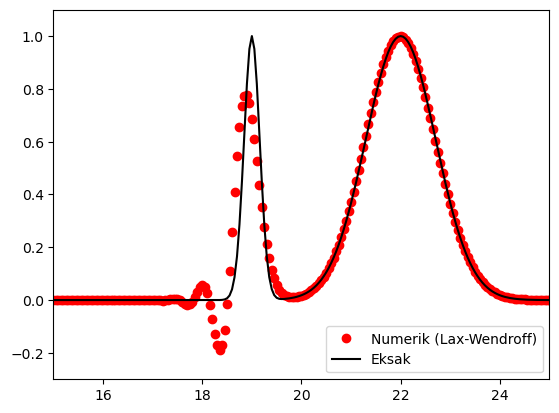

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fungsi solusi eksak
u_true = lambda x, t: np.exp(-20.0 * ((x - t) - 2.0)**2) + np.exp(-((x - t) - 5.0)**2)

# Grid
m = 501
x = np.linspace(0, 25.0, m)
delta_x = 25.0 / (m - 1)

# Parameter waktu
cfl = 0.8
delta_t = cfl * delta_x

# Kondisi awal
U = u_true(x, 0)
U_new = np.empty_like(U)

t = 0.0
t_final = 17.0

# Time stepping
while t < t_final:
    if t + delta_t > t_final:
        delta_t = t_final - t

    # Boundary kiri (periodik)
    U_new[0] = (
        U[0]
        - delta_t / (2.0 * delta_x) * (U[1] - U[-1])
        + delta_t**2 / (2.0 * delta_x**2) * (U[1] - 2.0 * U[0] + U[-1])
    )

    # Interior
    U_new[1:-1] = (
        U[1:-1]
        - delta_t / (2.0 * delta_x) * (U[2:] - U[:-2])
        + delta_t**2 / (2.0 * delta_x**2) * (U[2:] - 2.0 * U[1:-1] + U[:-2])
    )

    # Boundary kanan (periodik)
    U_new[-1] = (
        U[-1]
        - delta_t / (2.0 * delta_x) * (U[0] - U[-2])
        + delta_t**2 / (2.0 * delta_x**2) * (U[0] - 2.0 * U[-1] + U[-2])
    )

    U[:] = U_new
    t += delta_t

# Plot
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(x, U, 'ro', label='Numerik (Lax-Wendroff)')
axes.plot(x, u_true(x, t), 'k', label='Eksak')

axes.set_xlim((15.0, 25.0))
axes.set_ylim((-0.3, 1.1))
axes.legend()

plt.show()

### Contoh Soal:
Gunakan metode Lax-Friedrichs untuk menyelesaikan:
$ u_t + u_x = 0 $
dengan kondisi awal Gaussian.
Bandingkan hasil numerik dengan solusi eksak.

### Penyelesaian Langkah demi Langkah

#### 1. Persamaan dasar
u_t + u_x = 0

#### 2. Ide metode
Mengganti nilai tengah dengan rata-rata:
U_j^n → 1/2 (U_{j-1}^n + U_{j+1}^n)

#### 3. Rumus metode
U_j^{n+1} = 1/2 (U_{j-1}^n + U_{j+1}^n)
            - (Δt/(2Δx))(U_{j+1}^n - U_{j-1}^n)

#### 4. Interpretasi
- Bagian pertama → difusi (perataan)
- Bagian kedua → adveksi (pergerakan)

#### 5. Langkah penyelesaian
1. Tentukan grid x dan waktu
2. Definisikan kondisi awal Gaussian
3. Hitung nilai U di setiap titik
4. Iterasi menggunakan rumus
5. Bandingkan dengan solusi eksak

#### 6. Solusi eksak
u(x,t) = u0(x - t)

#### 7. Catatan
- Stabil jika |ν| ≤ 1
- Mengandung difusi numerik (hasil jadi lebih halus)

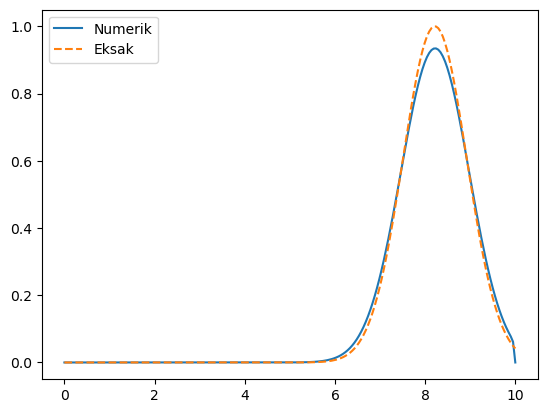

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def u0(x):
    return np.exp(-((x-5)**2))

nx = 200
x = np.linspace(0, 10, nx)
dx = x[1]-x[0]
dt = 0.8 * dx
nt = 80

u = u0(x)

for n in range(nt):
    u_new = u.copy()
    u_new[1:-1] = 0.5*(u[2:] + u[:-2]) - dt/(2*dx)*(u[2:] - u[:-2])
    u = u_new

plt.plot(x, u, label="Numerik")
plt.plot(x, u0(x - nt*dt), '--', label="Eksak")
plt.legend()
plt.show()

### Metode Upwind

Menganalisis metode Lax-Wendroff mengikuti pendekatan yang kami ambil terhadap metode Lax-Friedrichs dengan pertimbangan metode umum menggunakan matriks $A_\epsilon$.  Di sini, alih-alih $\epsilon = \Delta x^2 / 2 \Delta t$ kami menggunakan $\epsilon = a^2 \Delta t / 2$ .  Nilai eigen dari $A_\epsilon$ ini adalah
 $$
    \Delta t \lambda_p = -i \frac{a \Delta t}{\Delta x} \sin(p \pi \Delta x) + \left( \frac{a \Delta t}{\Delta x} \right)^2 (\cos(p \pi \Delta x) - 1).
$$ 
Dari contoh numerik di atas kita melihat bahwa ini terletak di dalam metode Euler dan memiliki batasan stabilitas yang sama dengan Lax-Friedrichs.  Ini bagus karena kami memperkirakan Lax-Wendroff berada di urutan kedua dengan akurat dalam ruang dan waktu, sementara Lax-Friedrichs hanya berada di urutan pertama.

Catatan pengamatan lain adalah bahwa nilai eigen untuk metode Lax-Wendroff tampaknya terlihat "optimal" mendekati batas wilayah stabilitas.  Hal ini disebabkan sifat orde kedua dari metode Lax-Wendroff dan mempunyai sifat bagus yaitu menggunakan jumlah redaman minimal yang diperlukan agar tetap stabil.

In [ ]:
# Plot eigenvalues of the matrix A_\epsilon and plot relative 
# absolute stability region

def construct_A(epsilon, a=1.0, delta_x=0.02):
    """Construct the matrix A from Leveque (10.15)
    """
    e = numpy.ones(int(1.0 / delta_x))
    A = numpy.diag(e[1:], 1) - numpy.diag(e[1:], -1)
    A[0, -1] = -1
    A[-1, 0] = 1
    
    B = numpy.diag(-2.0 * e, 0) + numpy.diag(e[1:], 1) + numpy.diag(e[1:], -1)
    B[0, -1] = 1
    B[-1, 0] = 1
    
    return -a / (2.0 * delta_x) * A + epsilon / delta_x**2 * B
    
delta_x = 0.02
delta_t = 0.8 * delta_x
a = 1.0
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 4)
titles = ["Forward Euler", "", "", "Lax-Wendroff", "Lax-Friedrichs", ""]
for (i, epsilon) in enumerate((0.0, 0.001, 0.005, 0.008, 0.0125, 0.014)):
    axes = fig.add_subplot(4, 2, i + 1, aspect='equal')
    
    # Plot eigenvalues
    eigenvalues = numpy.linalg.eigvals(construct_A(epsilon, a, delta_x))
    axes.plot(delta_t * eigenvalues.real, delta_t * eigenvalues.imag, 'ro')
    
    # Plot offset circle
    theta = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
    axes.plot(numpy.sin(theta) - 1.0, numpy.cos(theta), 'k')
    
    axes.set_xlim((-2.5, 0.5))
    axes.set_ylim((-1.5, 1.5))
    axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))
    
    axes.plot([-2.5, 0.5], [0.0, 0.0], color='lightgray')
    axes.plot([0.0, 0.0], [-1.5, 1.5], color='lightgray')
    
plt.show()

### Contoh Soal
Gunakan analisis Von Neumann untuk menentukan
kondisi stabilitas metode Upwind pada persamaan:

$ u_t + a u_x = 0 $

dengan $ a > 0. $



### Skema Upwind ($a > 0$)

$ \frac{u_i^{n+1} - u_i^n}{\Delta t} + a \frac{u_i^n - u_{i-1}^n}{\Delta x} = 0 $

Susun ulang:

$ u_i^{n+1} = u_i^n - \frac{a \Delta t}{\Delta x}(u_i^n - u_{i-1}^n) $

Definisikan bilangan Courant:

$ C = \frac{a \Delta t}{\Delta x} $

Sehingga:

$ u_i^{n+1} = u_i^n - C (u_i^n - u_{i-1}^n) $

-

### Analisis Von Neumann

Asumsikan solusi:

$ u_i^n = G^n e^{i k x_i} $

Substitusi ke skema:

$ G e^{i k x_i} = e^{i k x_i} - C (e^{i k x_i} - e^{i k x_{i-1}}) $

Karena:

$ x_{i-1} = x_i - \Delta x $

maka:

$ e^{i k x_{i-1}} = e^{i k x_i} e^{-i k \Delta x} $

Sehingga diperoleh:

$ G = 1 - C(1 - e^{-i k \Delta x}) $



### Faktor Amplifikasi

Gunakan:

$ e^{-i\theta} = \cos\theta - i \sin\theta $

dengan $\theta = k \Delta x$, maka:

$ G = 1 - C(1 - \cos\theta + i \sin\theta) $

Pisahkan:

$ G = (1 - C + C\cos\theta) - i C \sin\theta $



### Syarat Stabilitas

Stabil jika:

$ |G| \le 1 $

Hitung:

$ |G|^2 = (1 - C + C\cos\theta)^2 + (C \sin\theta)^2 $

Hasil analisis memberikan syarat:

$ 0 \le C \le 1 $



### Kesimpulan

Metode Upwind stabil jika:

$ 0 \le \frac{a \Delta t}{\Delta x} \le 1 $

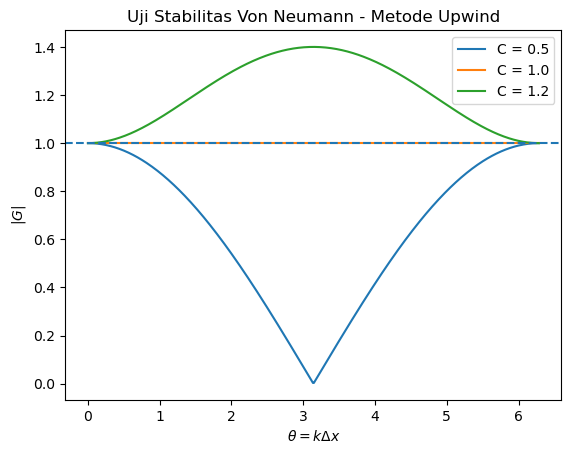

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Nilai Courant yang diuji
C_values = [0.5, 1.0, 1.2]

# Domain theta
theta = np.linspace(0, 2*np.pi, 500)

plt.figure()

for C in C_values:
    # Real dan imajiner dari G
    G_real = 1 - C * (1 - np.cos(theta))
    G_imag = -C * np.sin(theta)
    
    # Modulus |G|
    G_abs = np.sqrt(G_real**2 + G_imag**2)

    plt.plot(theta, G_abs, label=f'C = {C}')

# Garis batas stabilitas
plt.axhline(1, linestyle='--')

plt.xlabel(r'$\theta = k \Delta x$')
plt.ylabel(r'$|G|$')
plt.title('Uji Stabilitas Von Neumann - Metode Upwind')
plt.legend()

plt.show()

## Metode Melawan Angin

Salah satu aspek persamaan adveksi sederhana yang kami pertimbangkan yang belum dieksploitasi adalah asimetri persamaan akibat $a$ .  Jika $a > 0$ maka gelombang merambat ke kanan dan jika $a < 0$ merambat ke kiri.  Hal ini menunjukkan bahwa mungkin perbedaan satu sisi saja sudah cukup untuk memperkirakan solusi dibandingkan dengan pendekatan terpusat yang selama ini kita pertimbangkan.

Pertimbangkan perbedaan sepihak
 $$
    u_x(x_j, t) \approx \frac{1}{\Delta x} (U_j - U_{j-1}) \quad \text{and} \quad u_x(x_j, t) \approx \frac{1}{\Delta x} (U_{j+1} - U_{j})
$$ 
keduanya merupakan perkiraan akurat orde pertama terhadap turunan pertama.  Menggunakan ini bersama dengan skema loncatan waktu Euler ke depan mengarah ke
 $$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_j - U^n_{j-1}) \quad \text{or} \quad U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U_{j+1} - U_{j})
$$ 
yang kemudian merupakan skema urutan pertama dalam ruang dan waktu.

Jadi bagaimana kita mengeksploitasi asimetri yang disebutkan karena $a$ dan perbedaan satu sisi kita?

Solusi sebenarnya dari persamaan adveksi di titik $(x_j, t + \Delta t)$ adalah
 $$
    u(x_j, t + \Delta t) = u(x_j - a \Delta t, t)
$$ 
mewakili gagasan bahwa nilai solusi pada $u(x_j, t)$ "mengalir" ke titik baru (mengikuti ciri-cirinya).  Dalam kasus di mana $a > 0$ solusinya ditentukan oleh titik di sebelah kiri $x_j$ , khususnya di $x_j - a \Delta t$ .  Jika $a < 0$ maka ditentukan oleh titik di sebelah kanan $x_j$ .

Ini menunjukkan bahwa kita mungkin ingin menggunakan metode ini
 $$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_j - U^n_{j-1})
$$ 
jika $a > 0$ dan
 $$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U_{j+1} - U_{j})
$$ 
jika $a < 0$ .  Metode ini disebut *metode melawan arah angin* karena menggunakan titik "melawan arah angin" dari titik saat ini untuk menemukan solusinya.

In [ ]:
# Implement the Upwind method for the PDE u_t + u_x = 0 on a periodic
# domain
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

m = 501
x = numpy.linspace(0, 25.0, m)
delta_x = 25.0 / (m - 1)
cfl = 0.8
delta_t = cfl * delta_x

U = u_true(x, 0)
U_new = numpy.empty(U.shape)
t = 0.0
t_final = 17.0
while t < t_final:
    U_new[0] = U[0] - delta_t / delta_x * (U[0] - U[-1])
    #U_new[1:-1] = U[1:-1] - delta_t / delta_x * (U[1:-1] - U[:-2])
    #U_new[-1] = U[-1] - delta_t / delta_x * (U[-1] - U[-2])
    #Periodic boundaries will wrap in vectorized operation anyways
    U_new[1:] = U[1:] - delta_t / delta_x * (U[1:] - U[:-1])
    U = U_new.copy()
    t += delta_t
    
# Plot solution at t = 17.0 and t = 0.0
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, 'ro')
axes.plot(x, u_true(x, t),'k')
axes.set_xlim((15.0, 25.0))
axes.set_ylim((-0.3, 1.1))

plt.show()

### Stabilitas

Sekarang mari kita periksa stabilitas metode melawan arah angin ini.  Kita dapat menulis ulang metode melawan arah angin untuk $a > 0$ dengan
 $$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_j - U^n_{j-1}) + \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - 2 U^n_j + U^n_{j-1})
$$ 
mengarah ke $\epsilon = a \Delta x / 2$ yang efektif.

Kita tahu dari metode analisis garis bahwa metode seperti ini akan stabil jika
 $$
    \left |\frac{a \Delta t}{\Delta x} \right | \leq 1
$$ 
dan
 $$
    -2 < -\frac{2 \epsilon \Delta t}{\Delta x^2} < 0.
$$

Untuk Lax-Friedrichs $\epsilon$ adalah independen dari $a$ dan Lax-Wendroff $\epsilon$ memiliki $a^2$ jadi $\epsilon > 0$ dan oleh karena itu kondisi kedua ini akan dipenuhi dengan batasan yang sesuai pada $\Delta t$ dan $\Delta x$ di batas bawah.  Untuk metode melawan arah angin, hal ini tidak berlaku lagi karena tanda $a$ dapat menyebabkan $\epsilon < 0$ .  Faktanya, hal ini mengarah pada kondisi yang memberi tahu kita bentuk metode melawan arah angin seperti apa yang perlu kita gunakan bergantung pada tanda $a$.

Untuk metode yang dianalisis di atas kami miliki
 $$
    -2 < -\frac{2 \epsilon \Delta t}{\Delta x^2} < 0 \quad \Rightarrow 0 \leq \frac{a \Delta t}{\Delta x} \leq 1
$$ 
yang kita tahu akan memenuhi batas atas jika $a > 0$ .

Untuk metode melihat ke kanan kita punya syaratnya
 $$
    -2 < -\frac{2 \epsilon \Delta t}{\Delta x^2} < 0 \quad \Rightarrow -1 \leq \frac{a \Delta t}{\Delta x} \leq 0.
$$

Kita juga dapat memplot kembali nilai eigen matriks dan melihat apa yang terjadi pada setiap kasus.  Mengaitkan kembali nilai-nilai $\epsilon$ ini dengan nilai-nilai untuk Lax-Friedrichs dan Lax-Wendroff yang kita miliki
 $$
    \epsilon_{LW} = \frac{a^2 \Delta t}{2} = \frac{a \Delta x \nu}{2} \quad \epsilon_{UP} = \frac{a \Delta x}{2} \quad \epsilon_{LF} = \frac{\Delta x^2}{2 \Delta t} = \frac{a \Delta x}{2 \nu}
$$ 
dimana $\nu = a \Delta t / \Delta x$ (disebut nomor Courant).  Perhatikan itu 
 $$
    \epsilon_{LW} = \nu \epsilon_{UP} \quad \text{and} \quad \epsilon_UP = \nu \epsilon_{LF}
$$ 
dan jika $0 < \nu < 1$ maka kita tahu bahwa $\epsilon_{LW} < \epsilon_{UP} < \epsilon_{LF}$ .  Dengan kata lain kita melihat lagi bahwa Lax-Wendroff dan Lax-Friedrichs membentuk batas nilai $\epsilon$ yang tetap stabil dan metode melawan arah angin berada di antara kedua ekstrem tersebut.

In [ ]:
# Plot eigenvalues of the matrix A_\epsilon and plot relative 
# absolute stability region

def construct_A(epsilon, a=1.0, delta_x=0.02):
    """Construct the matrix A from Leveque (10.15)
    """
    e = numpy.ones(int(1.0 / delta_x))
    A = numpy.diag(e[1:], 1) - numpy.diag(e[1:], -1)
    A[0, -1] = -1
    A[-1, 0] = 1
    
    B = numpy.diag(-2.0 * e, 0) + numpy.diag(e[1:], 1) + numpy.diag(e[1:], -1)
    B[0, -1] = 1
    B[-1, 0] = 1
    
    return -a / (2.0 * delta_x) * A + epsilon / delta_x**2 * B
    
delta_x = 0.02
delta_t = 0.8 * delta_x
a = 1.0
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
titles = ["Upwind - Left", "Upwind - Right"]
for (i, epsilon) in enumerate((a * delta_x / 2.0, -a * delta_x / 2.0)):
    axes = fig.add_subplot(1, 2, i + 1, aspect='equal')
    
    # Plot eigenvalues
    eigenvalues = numpy.linalg.eigvals(construct_A(epsilon, a, delta_x))
    axes.plot(delta_t * eigenvalues.real, delta_t * eigenvalues.imag, 'ro')
    
    # Plot offset circle
    theta = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
    axes.plot(numpy.sin(theta) - 1.0, numpy.cos(theta), 'k')
    
    axes.set_xlim((-2.5, 0.5))
    axes.set_ylim((-1.5, 1.5))
    axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))
    
    axes.plot([-2.5, 0.5], [0.0, 0.0], color='lightgray')
    axes.plot([0.0, 0.0], [-1.5, 1.5], color='lightgray')
    
plt.show()

### Contoh Soal
Gunakan analisis Von Neumann untuk menentukan
kondisi stabilitas metode Upwind pada persamaan:

$ u_t + a u_x = 0 $

dengan $ a > 0. $

### Penyelesaian Langkah demi Langkah

#### Persamaan dasar
$ u_t + a u_x = 0 $
#### Diskritisasi metode Upwind (a > 0)
$ U_j^{n+1} = U_j^n - (aΔt/Δx)(U_j^n - U_{j-1}^n)$ 

Definisikan:
$ ν = aΔt/Δx  (bilangan Courant) $

Sehingga:
$ U_j^{n+1} = U_j^n - ν(U_j^n - U_{j-1}^n) $


#### Asumsi solusi Fourier (Von Neumann)
$ U_j^n = g^n e^{iξjΔx} $

di mana:
g = faktor amplifikasi
ξ = bilangan gelombang



#### Substitusi ke skema numerik

Sisi kiri:
$ U_j^{n+1} = g^{n+1} e^{iξjΔx} $

Sisi kanan:
$ U_j^n = g^n e^{iξjΔx} $
$ U_{j-1}^n = g^n e^{iξ(j-1)Δx} = g^n e^{iξjΔx} e^{-iξΔx} $ 

Substitusi:
$ g^{n+1} e^{iξjΔx} = g^n e^{iξjΔx} - ν(g^n e^{iξjΔx} - g^n e^{iξjΔx} e^{-iξΔx}) $



#### Sederhanakan
Bagi dengan $ g^n e^{iξjΔx}:$

$ g = 1 - ν(1 - e^{-iξΔx}) $


#### Bentuk akhir faktor amplifikasi
$ g = (1 - ν) + ν e^{-iξΔx} $


#### Analisis stabilitas
Syarat stabil:
$ |g| ≤ 1 $

Karena $ e^{-iξΔx} $ berada pada lingkaran satuan,
maka nilai maksimum |g| terjadi saat ekstrem.

Hasil:
$ 0 ≤ ν ≤ 1 $

#### Kesimpulan
Metode Upwind stabil jika:
$ 0 ≤ aΔt/Δx ≤ 1 $

Artinya:
$ Δt ≤ Δx / a $


#### Interpretasi fisik
- ν kecil → solusi stabil dan halus
- ν mendekati 1 → solusi masih stabil
- ν > 1 → solusi tidak stabil (numerik meledak)

'Nilai maksimum |g| = 1.0'

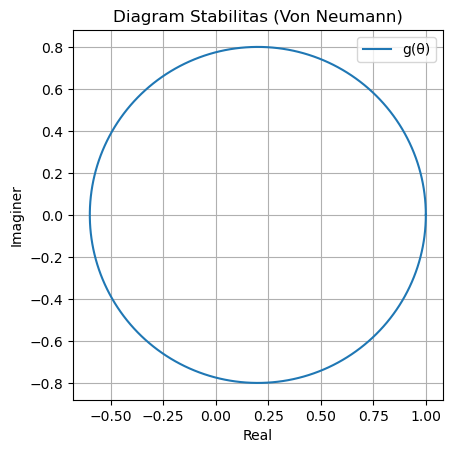

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Courant number
nu = 0.8

# domain frekuensi
theta = np.linspace(0, 2*np.pi, 200)

# faktor amplifikasi
g = (1 - nu) + nu * np.exp(-1j * theta)

display(f"Nilai maksimum |g| = {np.max(np.abs(g))}")

# plot
plt.figure()
plt.plot(g.real, g.imag, label="g(θ)")
plt.gca().set_aspect('equal')
plt.title("Diagram Stabilitas (Von Neumann)")
plt.xlabel("Real")
plt.ylabel("Imaginer")
plt.grid()
plt.legend()
plt.show()

### Metode Pemanasan Sinar

Anda mungkin bingung karena kami telah kembali ke metode orde pertama tetapi jangan takut, *Metode Pemanasan Sinar* adalah metode akurat orde kedua dengan jenis properti satu sisi yang sama.  Jika kita kembali ke perluasan yang kita temukan saat menurunkan metode Lax-Wendroff
 $$
    u(x, t + \Delta t) = u(x,t) - a \Delta t u_x(x,t) + \frac{a^2 \Delta t^2}{2} u_{xx}(x,t) + \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4)
$$ 
dan memperkirakan turunannya menggunakan perbedaan satu sisi, bukan perbedaan tengah, yang kita peroleh untuk $a > 0$ 
 $$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (3 U^n_j - 4 U^n_{j-1} + U^n_{j-2}) + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_j - 2 U^n_{j-1} + U^n_{j-2})
$$ 
dan untuk $a < 0$ 
 $$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (-3 U^n_j + 4 U^n_{j+1} - U^n_{j+2}) + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_j - 2 U^n_{j+1} + U^n_{j+2}).
$$ 
Metode ini stabil jika masing-masing $0 \leq \nu \leq 2$ dan $-2 \leq \nu \leq 0$.

In [ ]:
# Implement the Beam-Warming method for the PDE u_t + u_x = 0 on a periodic
# domain
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

m = 501
x = numpy.linspace(0, 25.0, m)
delta_x = 25.0 / (m - 1)
cfl = 0.8
delta_t = cfl * delta_x

U = u_true(x, 0)
U_new = numpy.empty(U.shape)
t = 0.0
t_final = 17.0
while t < t_final:
    U_new[0] = U[0] - delta_t / (2.0 * delta_x) * (3.0 * U[0] - 4.0 * U[-1] + U[-2]) \
                + delta_t**2 / (2.0 * delta_x**2) * (U[0] - 2.0 * U[-1] + U[-2])
    U_new[1] = U[1] - delta_t / (2.0 * delta_x) * (3.0 * U[1] - 4.0 * U[0] + U[-1]) \
                + delta_t**2 / (2.0 * delta_x**2) * (U[1] - 2.0 * U[0] + U[-1])
    U_new[2:] = U[2:] - delta_t / (2.0 * delta_x) * (3.0 * U[2:] - 4.0 * U[1:-1] + U[:-2]) \
                      + delta_t**2 / (2.0 * delta_x**2) * (U[2:] - 2.0 * U[1:-1] + U[:-2])
    U = U_new.copy()
    t += delta_t
    
# Plot solution at t = 17.0 and t = 0.0
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, 'ro')
axes.plot(x, u_true(x, t),'k')
axes.set_xlim((15.0, 25.0))
axes.set_ylim((-0.3, 1.1))

plt.show()

## Analisis Von Neumann

Kami sekarang mencoba untuk mendapatkan kendala serupa seperti yang kita lihat dengan metode diskritisasi garis tetapi menggunakan analisis von Neumann.

Ingatlah bahwa analisis von Neumann dilanjutkan dengan mengganti $U^n_j$ dengan $g(\xi)^n e^{i \xi j \Delta x}$ dan menemukan ekspresi untuk faktor amplifikasi $g(\xi)$ .  Jika faktor amplifikasi memenuhi
 $$
    \left|g(\xi)\right| \leq 1
$$ 
maka kita tahu metode tersebut stabil.

Di bawah ini kami juga akan memperkenalkan notasinya
 $$
    \nu \equiv \frac{a \Delta t}{\Delta x}
$$ 
karena akan berguna di kemudian hari.

### Contoh - Melawan Angin

Metode melawan arah angin untuk $a > 0$ adalah 
 $$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x}(U^n_{j} - U^n_{j - 1}).
$$ 
Turunkan faktor amplifikasi dan kondisi stabilitas yang dihasilkan.

Memasukkan solusi gelombang bidang yang kita miliki
 $$\begin{aligned}
    g(\xi) &= 1 - \frac{a \Delta t}{\Delta x} (1 - e^{-i \xi \Delta x}) \\
    &= (1 - \nu) + \nu e^{-i \xi \Delta x}.
\end{aligned}$$ 
Faktor amplifikasi ini bervariasi dengan bilangan gelombang $\xi$ sehingga membentuk lingkaran berjari-jari $\nu$ yang berpusat di $1 - \nu$ .  Perhatikan bahwa jika $\nu = 1$ lingkaran berpusat di titik asal dan berjari-jari 1, yaitu bola satuan.  Dengan kata lain, mereka berada di ambang kestabilan.  Ekstrem lainnya dengan $\nu = 0$ tidak begitu menarik (karena ini adalah kasus sepele dengan $a = 0$ ).  Kesimpulannya maka untuk kestabilan harus ada metode melawan arah angin
 $$
    0 \leq \nu \leq 1.
$$ 

Untuk kasus $a < 0$ kami menemukan kasus analog dengan $-1 \leq \nu \leq 0$ .

### Contoh - Lax-Wendroff

Turunkan faktor amplifikasi untuk metode Lax-Wendroff
 $$
     U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})  + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j+1} - 2 U^n_{j} + U^n_{j-1})
$$

$$\begin{aligned}
    g(\xi) &= 1 - \frac{\nu}{2} \left(e^{i \xi \Delta x} - e^{-i \xi \Delta x} \right ) + \frac{\nu^2}{2} \left (e^{i \xi \Delta x} - 2 + e^{-i \xi \Delta x} \right ) \\
    &= 1 - i \nu \sin(\xi \Delta x) + \nu^2 (\cos(\xi \Delta x) - 1) \\
    &= 1 - i \nu 2\sin(\xi \Delta x / 2) \cos(\xi \Delta x / 2) - \nu^2 2\sin(\xi \Delta x / 2)
\end{aligned}$$ 
(baris terakhir ditulis agar kita mudah mengambil modulusnya).

 $$\begin{aligned}
    |g(\xi)|^2 &= (1 - 2\nu^2 \sin^2(\xi \Delta x / 2) )^2 + 4 \nu^2 \sin^2(\xi \Delta x / 2) \cos^2(\xi \Delta x / 2) \\
    &= 1 + 4 \nu^2 \sin^2(\xi \Delta x / 2) (\cos^2(\xi \Delta x / 2) - 1) + 4\nu^4 \sin^4(\xi \Delta x / 2) \\
    &=1 -4 \nu^2 (1 - \nu^2) \sin^4(\xi \Delta x / 2).
\end{aligned}$$ 
Kita mengetahui $0 \leq \sin^4(\xi \Delta x / 2) \leq 1$ untuk $\xi$ apa pun sehingga kita memerlukan $|\nu| \leq 1$ agar metodenya stabil.

### Contoh - Lax-Friedrichs

Turunkan faktor amplifikasi untuk Lax-Friedrichs
 $$
    U^{n+1}_j = \frac{1}{2}(U^n_{j-1} + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$

$$\begin{aligned}
    g(\xi) &= \frac{1}{2} (e^{i \xi \Delta x} + e^{-i \xi \Delta x}) - \frac{\nu}{2} (e^{i \xi \Delta x} - e^{-i \xi \Delta x}) \\
    &= \cos(\xi \Delta x) - i \nu \sin(\xi \Delta x)
\end{aligned}$$ 
mengarah ke
 $$
    |g(\xi)|^2 = \cos^2(\xi \Delta x) + \nu^2 \sin^2 (\xi \Delta x)
$$ 
dan oleh karena itu kondisinya $|\nu| \leq 1$ .

### Contoh - leapfrog


Sedikit lebih rumit namun bisa dilakukan, dapatkan faktor amplifikasi dan kriteria stabilitas untuk metode leapfrog
 $$
    U^{n+1}_j = U^{n-1}_j - \frac{a \Delta t}{\Delta x} (U^n_{j+1} - U^n_{j-1})
$$

$$\begin{aligned}
     g(\xi)^2 &= 1 - \nu g(\xi) (e^{i \xi \Delta x} - e^{-i \xi \Delta x}) \\
     &= 1- 2 \nu i \sin(\xi \Delta x) g(\xi). 
\end{aligned}$$ 
Ini kemudian menyiratkan dua cabang untuk $g(\xi)$ :
 $$
    g_{1,2}(\xi) =  - \nu i \sin(\xi \Delta x) \pm \sqrt{1 - \nu^2 \sin^2(\xi \Delta x)}
$$ 
dan oleh karena itu modulus dari
 $$
    |g_{1,2}(\xi)|^2 =  \nu^2 \sin^2(\xi \Delta x) + ( 1 - \nu^2 \sin^2(\xi \Delta x)) \leq 1
$$ 
jika $|\nu| \leq 1$ lagi.